In [ ]:
import pandas as pd
import numpy as np
import time
import pickle 

from sbi.utils import BoxUniform
from scipy.integrate import odeint
from sbi.utils import MultipleIndependent


import matplotlib.pyplot as plt

import torch
from torch.distributions import Uniform, Exponential, Cauchy

_ = torch.manual_seed(0)
_ = np.random.seed(0)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using device:", device)                                                                                                                                                                                                                                                                                                                               

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


Using device: cpu


In [2]:
import pyabc
from pyabc import ABCSMC, Distribution, RV
import tempfile

pyabc.settings.set_figure_params('pyabc') 

from DDE_s import *
from Parameters_s import *
import sympy
from jitcdde import y, t, jitcdde

import warnings
warnings.filterwarnings("ignore")

In [3]:
all_control_parameters_sym = list(sympy_params.values()) + list(sympy_delays.values())
current_control_parameter_values = [params[k] for k in sympy_params.keys()] + [T_delay[k] for k in sympy_delays.keys()]
param_to_index = {sym: i for i, sym in enumerate(all_control_parameters_sym)}
max_delay_value = max(T_delay.values())

In [4]:
def sample_prior(n):
    return {
        'beta': np.random.uniform(0.6, 1.2, n),
        'phi_s': np.random.uniform(0.2, 0.6, n),
        'g_rate': np.random.uniform(0.005, 0.01, n),
    }

In [ ]:
with open('../../Data/Model3/sim_dataset.pkl', 'rb') as handle:
    simulation_dataset = pickle.load(handle)

In [6]:
times = np.linspace(0, N_t, N_t * sample_num_factor+1)

In [ ]:
def sampleResult(yy):
    samp_index = [int(i) for i in np.linspace(0, N_t * sample_num_factor, N_t+1)]
    sampled_yy = []
    for t_i in samp_index:
        sampled_yy.append(yy[t_i])
    return sampled_yy


def simulate(parameters):
    beta, phi_s, g_rate = parameters
    
    current_control_parameter_values[param_to_index[sympy_params['beta']]]=beta
    current_control_parameter_values[param_to_index[sympy_params['beta_prime']]]=beta*1.2
    current_control_parameter_values[param_to_index[sympy_params['phi_s_1']]]=phi_s
    current_control_parameter_values[param_to_index[sympy_params['g_beta']]]=g_rate

    DDE = jitcdde(f, control_pars=all_control_parameters_sym, max_delay=max_delay_value)
    DDE.set_integration_parameters(atol=1e-6, rtol=1e-3)
    DDE.constant_past(init_cond)
    DDE.set_parameters(current_control_parameter_values)

    data = [DDE.integrate(time) for time in times]
    yy = sampleResult(data)
    
    return yy

def simulator(sim_par):
    beta = sim_par[0]
    phi_s = sim_par[1]
    g_rate = sim_par[2]

    yy = simulate(parameters=[beta, phi_s, g_rate])
    
    pos = []

    indices = np.arange(0, N_t * sample_num_factor, sample_num_factor)
    
    pos = [(yy[t][states['F_AT_1']] + yy[t][states['F_ST_1']]) * (params['True_P_1']) +
           (yy[t][states['F_AT_2']] + yy[t][states['F_ST_2']]) * (params['True_P_2']) +
           (1 - params["True_N_1"]) * (yy[t][states['F_NT_1']] + yy[t][states['F_AT_3']] +
                                       yy[t][states['F_FT_1']] + yy[t][states['F_GT1']] +
                                       yy[t][states['F_ST_4']] + yy[t][states['F_ST_3']] +
                                       yy[t][states['F_FT_3']]) +
           (1 - params["True_N_2"]) * (yy[t][states['F_NT_2']] + yy[t][states['F_AT_4']] +
                                       yy[t][states['F_FT_2']] + yy[t][states['F_GT2']]) for t in range(N_t)]

    
    neg = [(yy[t][states['F_AT_1']] + yy[t][states['F_ST_1']]) * (1 - params['True_P_1']) +
           (yy[t][states['F_AT_2']] + yy[t][states['F_ST_2']]) * (1 - params['True_P_2']) +
           params["True_N_1"] * (yy[t][states['F_NT_1']] + yy[t][states['F_AT_3']] +
                                 yy[t][states['F_FT_1']] + yy[t][states['F_GT1']] +
                                 yy[t][states['F_ST_4']] + yy[t][states['F_ST_3']] +
                                 yy[t][states['F_FT_3']]) +
           params["True_N_2"] * (yy[t][states['F_NT_2']] + yy[t][states['F_AT_4']] +
                                 yy[t][states['F_FT_2']] + yy[t][states['F_GT2']]) for t in range(N_t)]


    hospital = [sum(yy[t][states['F_H1']] + yy[t][states['F_H2']] + yy[t][states['F_H3']] for t in range(ti + 1)) for ti
                in range(N_t)]

    death = [yy[t][states['D']] for t in range(N_t)]

    return np.stack([pos, neg, hospital, death],axis=1)

In [ ]:
def poisson_noise(simulation):
    
    with_noise = np.random.poisson(np.maximum(simulation, 1e-6))

    return with_noise

In [11]:
duration=100

In [12]:
with open('../sim_dataset.pkl', 'rb') as file:
    simulation_dataset = pickle.load(file)

with open('../sim_dataset.pkl', 'rb') as file:
    simulation_dataset = pickle.load(file)

with open('./before/ABC_1k.pkl', 'rb') as file:
    results_1k = pickle.load(file)

with open('./before/ABC_10k.pkl', 'rb') as file:
    results_10k = pickle.load(file)

with open('./before/ABC_100k.pkl', 'rb') as file:
    results_100k = pickle.load(file)

In [13]:
duration=100

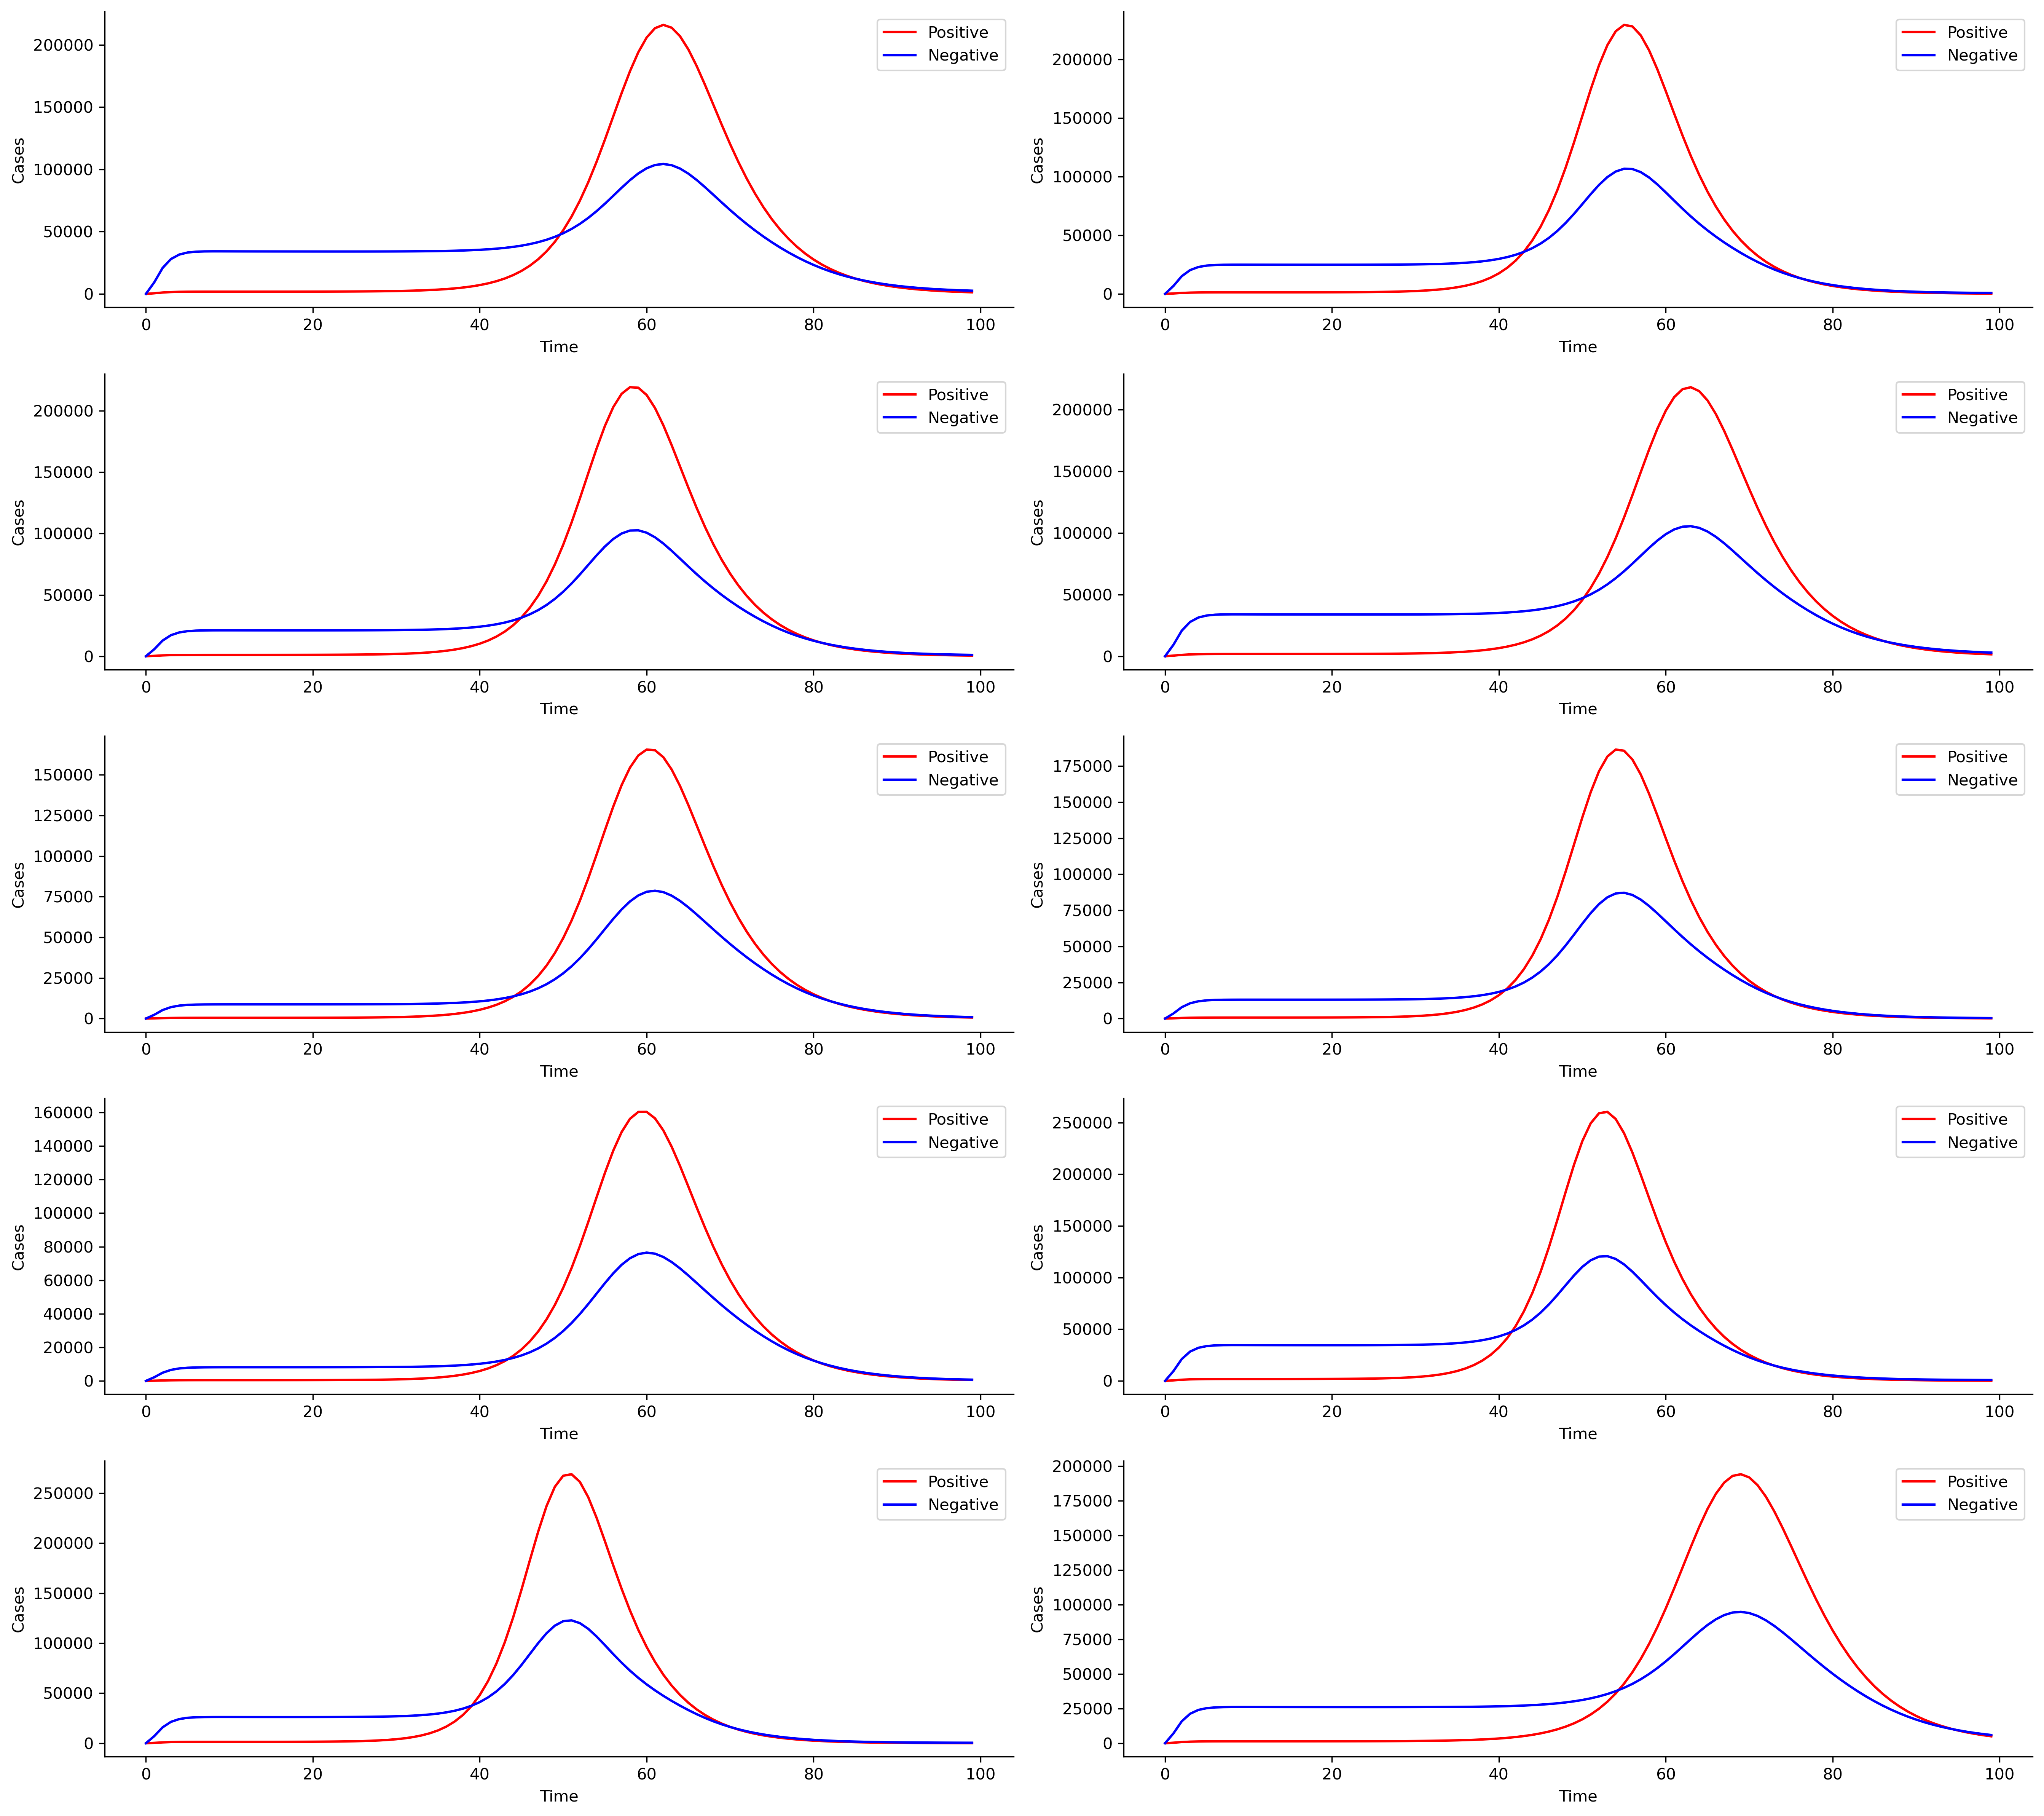

In [14]:
plt.figure(figsize=(18, 16),dpi=300)

for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.plot(np.arange(0,duration), simulation_dataset[i]['true'][:,0], color="red", label="Positive")
    plt.plot(np.arange(0,duration), simulation_dataset[i]['true'][:,1], color="blue", label="Negative")
    
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Cases")

plt.tight_layout()
plt.show()

In [15]:
prior = Distribution(
    beta = RV("uniform", 0.6, 1.2),
    phi_s = RV("uniform", 0.2, 0.6),
    g_rate  = RV("uniform", 0.005, 0.01),
)

In [16]:
param_names = ["beta", "phi_s", "g_rate"]

In [17]:
prior_samples_1k=[]
for i, res in enumerate(results_1k):  
    df, weights = res['posterior']
    df = df[param_names]
    
    kde_estimator = pyabc.transition.MultivariateNormalTransition()
    kde_estimator.fit(df, weights)
    
    num_samples = 500
    samples = kde_estimator.rvs(num_samples)
    prior_samples_1k.append(samples)

In [18]:
prior_samples_10k=[]
for i, res in enumerate(results_10k):  
    df, weights = res['posterior']
    df = df[param_names]
    
    kde_estimator = pyabc.transition.MultivariateNormalTransition()
    kde_estimator.fit(df, weights)
    
    num_samples = 5000
    samples = kde_estimator.rvs(num_samples)
    prior_samples_10k.append(samples)

In [19]:
prior_samples_100k=[]
for i, res in enumerate(results_100k): 
    df, weights = res['posterior']
    df = df[param_names]
    
    kde_estimator = pyabc.transition.MultivariateNormalTransition()
    kde_estimator.fit(df, weights)
    
    num_samples = 50000
    samples = kde_estimator.rvs(num_samples)
    prior_samples_100k.append(samples)

## SBI

In [20]:
import torch.nn as nn

class LSTMembedding(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, output_dim=30, num_layers=1,bidirectional=True):
        super().__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, bidirectional=bidirectional, batch_first = True)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x = x.unsqueeze(-1)  
        lstm_out, _ = self.lstm(x)  
        last_hidden = lstm_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)   
        return out

embedding_net =LSTMembedding(input_dim=4, hidden_dim=128, output_dim=30).to(device)
embedding_net

LSTMembedding(
  (lstm): LSTM(4, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=30, bias=True)
  (tanh): Tanh()
  (dropout): Dropout(p=0.1, inplace=False)
)

In [25]:
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn

ImportError: cannot import name 'NPE' from 'sbi.inference' (/home/gjang12/.conda/envs/sbi_env/lib/python3.11/site-packages/sbi/inference/__init__.py)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## 1k

In [27]:
num_samples = 500

In [37]:
mean=np.mean(xs,axis=(0,1))

In [39]:
std=np.std(xs,axis=(0,1))+1e-6

In [ ]:
infos=[]
pnpe_samples_1k=[]

for i in range(10):
    theta = torch.tensor(np.array(prior_samples_1k[i]),dtype=torch.float32)
    x_obs = simulation_dataset[i]['poisson'][:,:]
    xs = [poisson_noise(simulator(th)) for th in theta]
    thetas = theta
    
    mean = np.mean(xs,axis=(0,1))
    std = np.std(xs,axis=(0,1))+1e-6
    
    xs_norm = (xs-mean)/std
    xs_norm = torch.tensor(xs_norm, dtype=torch.float32)
    
    thetas=thetas.to(device)
    xs_norm=xs_norm.to(device)
    
    x_obs_norm=(x_obs-mean)/std
    x_obs_norm_tensor = torch.as_tensor(x_obs_norm, dtype=torch.float32).to(device)
    
    infos.append({
            'xs_norm': xs_norm,
            'x_obs_norm': x_obs_norm_tensor,
            'thetas': thetas,
            'mean': mean,
            'std': std
        })

    
    start_time = time.time()
    neural_posterior = posterior_nn(model='maf', embedding_net=embedding_net)
    inference = NPE(density_estimator=neural_posterior,device=device)
    density_estimator=inference.append_simulations(thetas, xs_norm).train(training_batch_size=32)
    end_time = time.time() 
    elapsed_time = end_time - start_time
    print(f"time.time(): {elapsed_time:.4f} seconds")

    posterior = inference.build_posterior(density_estimator)
    with open(f"./network/PNPE_1k_posterior_{i}.pkl", "wb") as handle:
        pickle.dump(posterior, handle)
    with open(f"./network/PNPE_1k_inference_{i}.pkl", "wb") as handle:
        pickle.dump(inference, handle)

    samples = posterior.sample((10000,), x=x_obs_norm_tensor)
    samples_df=pd.DataFrame(samples.cpu().tolist())
    pnpe_samples_1k.append(samples_df)

Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating,

In [ ]:
with open("./posterior/PNPE_1k.pkl", "wb") as file:
    pickle.dump(pnpe_samples_1k, file)

with open("./info/PNPE_1k.pkl", "wb") as file:
    pickle.dump(infos, file)

In [26]:
num_samples = 5000

In [27]:
prior_samples_10k[1]

name,beta,phi_s,g_rate
id,,,
1486,1.029147,0.414472,0.009094
1431,1.028785,0.416246,0.008483
1491,1.028645,0.400109,0.009178
1407,1.028733,0.408452,0.009327
1495,1.029195,0.406389,0.009449
...,...,...,...
1477,1.024578,0.400315,0.009269
1478,1.030388,0.420214,0.008812
1471,1.022942,0.392239,0.009214


In [29]:
for i in range(10):      
    theta_np = prior_samples_10k[i]
    X = simulate_many(prior_samples_10k[i], n_workers=24, chunk_size=256)
    
    X32 = X.astype(np.float32)
    theta32 = theta_np.astype(np.float32)
    
    np.savez_compressed(f"./data/sim_10k_{i}.npz", X=X32, theta=theta32)

NameError: name 'simulate_many' is not defined

name,beta,phi_s,g_rate
id,,,
1419,0.927763,0.520589,0.010061
1491,0.927094,0.516512,0.009882
1469,0.929291,0.509510,0.010026
1413,0.933844,0.543405,0.009205
1429,0.928838,0.514675,0.010174
...,...,...,...
1455,0.925355,0.505859,0.010011
1454,0.931406,0.523675,0.010156
1447,0.922960,0.496439,0.010076


In [47]:
infos=[]
pnpe_samples_10k=[]

for i in range(10):
    theta = torch.tensor(np.array(prior_samples_10k[i]),dtype=torch.float32)
    x_obs = simulation_dataset[i]['poisson'][:,:]
    xs = [poisson_noise(simulator(th)) for th in theta]
    thetas = theta
    
    mean = np.mean(xs,axis=(0,1))
    std = np.std(xs,axis=(0,1))+1e-6
    
    xs_norm = (xs-mean)/std
    xs_norm = torch.tensor(xs_norm, dtype=torch.float32)
    
    thetas=thetas.to(device)
    xs_norm=xs_norm.to(device)
    
    x_obs_norm=(x_obs-mean)/std
    x_obs_norm_tensor = torch.as_tensor(x_obs_norm, dtype=torch.float32).to(device)
    
    infos.append({
            'xs_norm': xs_norm,
            'x_obs_norm': x_obs_norm_tensor,
            'thetas': thetas,
            'mean': mean,
            'std': std
        })

    
    start_time = time.time()
    neural_posterior = posterior_nn(model='maf', embedding_net=embedding_net)
    inference = NPE(density_estimator=neural_posterior,device=device)
    density_estimator=inference.append_simulations(thetas, xs_norm).train(training_batch_size=32)
    end_time = time.time() 
    elapsed_time = end_time - start_time
    print(f"time.time(): {elapsed_time:.4f} seconds")

    posterior = inference.build_posterior(density_estimator)
    with open(f"./network/PNPE_10k_posterior_{i}.pkl", "wb") as handle:
        pickle.dump(posterior, handle)
    with open(f"./network/PNPE_10k_inference_{i}.pkl", "wb") as handle:
        pickle.dump(inference, handle)

    samples = posterior.sample((10000,), x=x_obs_norm_tensor)
    samples_df=pd.DataFrame(samples.cpu().tolist())
    pnpe_samples_10k.append(samples_df)

Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating, compiling, and loading C code.
Generating,

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3549, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_246/3808729647.py", line 7, in <module>
    xs = [poisson_noise(simulator(th)) for th in theta]
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_246/3808729647.py", line 7, in <listcomp>
    xs = [poisson_noise(simulator(th)) for th in theta]
                        ^^^^^^^^^^^^^
  File "/tmp/ipykernel_246/2674948528.py", line 6, in simulator
    yy = simulate(parameters=[beta, phi_s, g_rate])
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_246/4153355316.py", line 12, in simulate
    DDE.set_parameters(current_control_parameter_values)
  File "/usr/local/lib/python3.11/dist-packages/jitcdde/_jitcdde.py", line 606, in set_parameters
    self._initiate()
  File "/usr/local/lib/python3.11/dist-packages/jitcdde/_jitcdd

In [ ]:
with open("./posterior/PNPE_10k.pkl", "wb") as file:
    pickle.dump(pnpe_samples_10k, file)

with open("./info/PNPE_10k.pkl", "wb") as file:
    pickle.dump(infos, file)

In [ ]:
infos=[]
pnpe_samples_100k=[]

for i in range(10):
    theta = torch.tensor(np.array(prior_samples_100k[i]),dtype=torch.float32)
    x_obs = simulation_dataset[i]['poisson'][:,:]
    xs = [poisson_noise(simulator(th)) for th in theta]
    thetas = theta
    
    mean = np.mean(xs,axis=(0,1))
    std = np.std(xs,axis=(0,1))+1e-6
    
    xs_norm = (xs-mean)/std
    xs_norm = torch.tensor(xs_norm, dtype=torch.float32)
    
    thetas=thetas.to(device)
    xs_norm=xs_norm.to(device)
    
    x_obs_norm=(x_obs-mean)/std
    x_obs_norm_tensor = torch.as_tensor(x_obs_norm, dtype=torch.float32).to(device)
    
    infos.append({
            'xs_norm': xs_norm,
            'x_obs_norm': x_obs_norm_tensor,
            'thetas': thetas,
            'mean': mean,
            'std': std
        })

    
    start_time = time.time()
    neural_posterior = posterior_nn(model='maf', embedding_net=embedding_net)
    inference = NPE(density_estimator=neural_posterior,device=device)
    density_estimator=inference.append_simulations(thetas, xs_norm).train(training_batch_size=32)
    end_time = time.time() 
    elapsed_time = end_time - start_time
    print(f"time.time(): {elapsed_time:.4f} seconds")

    posterior = inference.build_posterior(density_estimator)
    with open(f"./network/PNPE_100k_posterior_{i}.pkl", "wb") as handle:
        pickle.dump(posterior, handle)
    with open(f"./network/PNPE_100k_inference_{i}.pkl", "wb") as handle:
        pickle.dump(inference, handle)

    samples = posterior.sample((10000,), x=x_obs_norm_tensor)
    samples_df=pd.DataFrame(samples.cpu().tolist())
    pnpe_samples_100k.append(samples_df)

In [ ]:
with open("./posterior/PNPE_100k.pkl", "wb") as file:
    pickle.dump(pnpe_samples_100k, file)

with open("./info/PNPE_100k.pkl", "wb") as file:
    pickle.dump(infos, file)